# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/suha-2004/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Can historical search and content signals be used to identify pages that should be prioritized for content review?

Decision supported: This analysis helps editors decide which pages should be reviewed or refreshed first.

Unit of analysis: Page.

Output: A ranked content-opportunity score with reasons for prioritization.

In [2]:
# Capstone setup

import os
import duckdb
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

print("Setup complete")

Setup complete


In [3]:
# Connect to the FlyRank full release

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not found. Add it to Colab Secrets.")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')"
}

print("FlyRank warehouse connected")

FlyRank warehouse connected


In [4]:
date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date
0,2025-01-27,2026-06-30


In [5]:
clients = con.sql(f"""
    SELECT
        client_hash_id,
        access_profile,
        gsc_data_start,
        ga4_data_start
    FROM {TABLES['dim_clients']}
""").df()

print("Number of clients:", len(clients))
clients.head()

Number of clients: 104


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,gsc_and_ga4,NaT,2026-05-22
1,client_05475c07ed21a83a,no_search_or_analytics_access,NaT,NaT
2,client_06d356715a8ff3b6,gsc_and_ga4,2026-04-10,2026-04-06
3,client_0797ff3a1fc9a6a5,no_search_or_analytics_access,2025-11-05,NaT
4,client_08a6a72ff48e62c0,gsc_only,2025-09-24,NaT


In [6]:
bounds = con.sql(f"""
    SELECT MAX(report_date) AS end_date
    FROM {TABLES['fact_daily']}
""").df()

end_date = bounds.loc[0, "end_date"]

print("Dataset end date:", end_date)

Dataset end date: 2026-06-30 00:00:00


In [7]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
    ),

    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_last30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_impressions
                    ELSE 0
                END
            ) AS imp_prev30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_clicks
                    ELSE 0
                END
            ) AS clk_last30,

            SUM(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_clicks
                    ELSE 0
                END
            ) AS clk_prev30,

            AVG(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_avg_position
                END
            ) AS pos_last30,

            AVG(
                CASE
                    WHEN f.report_date > b.end_d - INTERVAL 60 DAY
                     AND f.report_date <= b.end_d - INTERVAL 30 DAY
                    THEN f.gsc_avg_position
                END
            ) AS pos_prev30

        FROM {TABLES['fact_daily']} f
        CROSS JOIN bounds b

        WHERE f.report_date > b.end_d - INTERVAL 60 DAY

        GROUP BY
            f.client_hash_id,
            f.content_hash_id

        HAVING imp_prev30 >= 100
    )

    SELECT *
    FROM windowed
""").df()

print("Feature rows:", len(features))
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 111247


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,0.0,41.917435,28.525859
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,5.0,40.678875,29.404069
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.0,7.070556,8.193871
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,0.0,35.997698,30.401799
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,0.0,12.166371,13.851051


In [8]:
qsignals = con.sql(f"""
    SELECT
        content_hash_id,

        ANY_VALUE(content_visible_query_count)
            AS visible_queries,

        ANY_VALUE(rare_impressions_share)
            AS rare_share,

        ANY_VALUE(anonymized_impressions_share)
            AS anon_share,

        MAX(impressions_90d)
            AS top_query_impressions,

        SUM(impressions_90d)
            AS kept_impressions

    FROM {TABLES['fact_query_90d']}

    GROUP BY content_hash_id
""").df()

qsignals["top_query_share"] = (
    qsignals["top_query_impressions"] /
    qsignals["kept_impressions"]
)

data = features.merge(
    qsignals,
    on="content_hash_id",
    how="left"
)

print("Final feature table:", data.shape)

data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Final feature table: (111247, 14)


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_17d994b99d470434,252.0,827.0,1.0,0.0,41.917435,28.525859,8.0,0.136531,0.239391,1223.0,1353.0,0.903917
1,client_62f4a7e64f5e0096,content_9e6d399bb7df2d21,411.0,874.0,4.0,5.0,40.678875,29.404069,38.0,0.146092,0.336034,900.0,2173.0,0.414174
2,client_62f4a7e64f5e0096,content_889961fe0fd51a4b,2140.0,2664.0,6.0,7.0,7.070556,8.193871,42.0,0.064587,0.803004,103.0,1146.0,0.089878
3,client_62f4a7e64f5e0096,content_7e67ece7486a4851,101.0,183.0,0.0,0.0,35.997698,30.401799,4.0,0.384248,0.408115,38.0,87.0,0.436782
4,client_62f4a7e64f5e0096,content_762f7da095bfd414,141.0,261.0,0.0,0.0,12.166371,13.851051,3.0,0.104607,0.860845,15.0,36.0,0.416667


In [9]:
data["is_declining"] = (
    data["imp_last30"] <
    0.8 * data["imp_prev30"]
).astype(int)

print(data["is_declining"].value_counts())
print(data["is_declining"].value_counts(normalize=True))

is_declining
1    71547
0    39700
Name: count, dtype: int64
is_declining
1    0.643136
0    0.356864
Name: proportion, dtype: float64


In [10]:
feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "pos_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

In [11]:
model_data = data.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print("Rows available for modeling:", len(model_data))

Rows available for modeling: 102203


In [12]:
model_data["baseline_score"] = (
    1 -
    model_data["imp_prev30"] /
    model_data["imp_prev30"].median()
)

model_data["baseline_score"] = (
    model_data["baseline_score"]
    .clip(lower=0)
)

In [13]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_data,
        model_data["is_declining"],
        groups=model_data["client_hash_id"]
    )
)

train = model_data.iloc[train_idx].copy()
test = model_data.iloc[test_idx].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train clients:", train["client_hash_id"].nunique())
print("Test clients:", test["client_hash_id"].nunique())

Train rows: 50758
Test rows: 51445
Train clients: 39
Test clients: 10


In [14]:
print(
    "Client overlap:",
    len(
        set(train["client_hash_id"])
        &
        set(test["client_hash_id"])
    )
)

Client overlap: 0


In [15]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(
    train[feature_cols],
    train["is_declining"]
)

print("Model trained successfully")

Model trained successfully


In [16]:
test["model_score"] = model.predict_proba(
    test[feature_cols]
)[:, 1]

test["model_prediction"] = (
    test["model_score"] >= 0.5
).astype(int)

In [17]:
auc = roc_auc_score(
    test["is_declining"],
    test["model_score"]
)

precision = precision_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

recall = recall_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

f1 = f1_score(
    test["is_declining"],
    test["model_prediction"],
    zero_division=0
)

base_rate = test["is_declining"].mean()

print(f"Base rate : {base_rate:.3f}")
print(f"AUC       : {auc:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1        : {f1:.3f}")

Base rate : 0.679
AUC       : 0.643
Precision : 0.764
Recall    : 0.607
F1        : 0.677


In [18]:
def precision_at_k(df, score_col, label_col, k):
    ranked = df.sort_values(
        score_col,
        ascending=False
    ).head(k)

    return ranked[label_col].mean()


for k in [20, 50, 100]:
    p = precision_at_k(
        test,
        "model_score",
        "is_declining",
        k
    )

    print(f"Precision@{k}: {p:.3f}")

Precision@20: 0.850
Precision@50: 0.880
Precision@100: 0.920


In [19]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
2,pos_prev30,0.198074
4,rare_share,0.170290
0,imp_prev30,0.166661
5,anon_share,0.164480
6,top_query_share,0.133153
3,visible_queries,0.098586
1,clk_prev30,0.068757


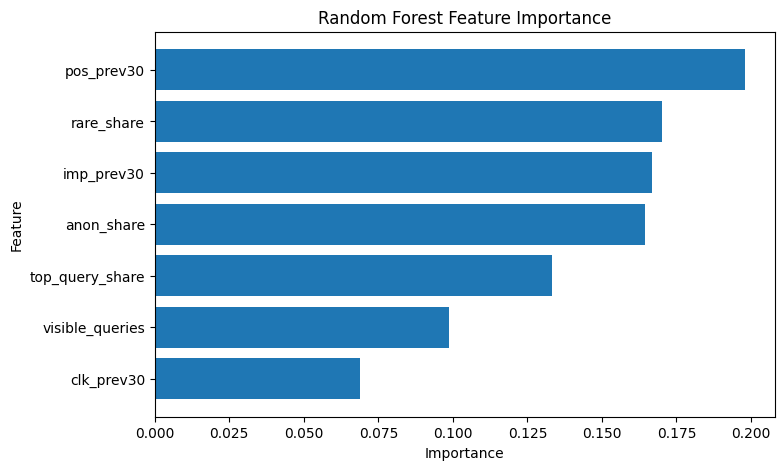

In [20]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [21]:
recommendations = test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
)

recommendations["rank"] = range(
    1,
    len(recommendations) + 1
)

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,rank
104518,client_73cda7b4e4f265ea,content_7ff28a307d4d3636,1.000000,1,1
63467,client_3197e6291363b4db,content_6bb5b6378e3d0608,1.000000,0,2
95825,client_62f4a7e64f5e0096,content_e93bfe2aeda97077,0.996667,1,3
40495,client_62f4a7e64f5e0096,content_b36b207918cb0140,0.993333,1,4
58569,client_fef1a8f436438636,content_c0b08a44b9470a8c,0.990000,1,5
39502,client_8ddc46da5414ffd8,content_3604fa8c0532b29c,0.990000,0,6
29149,client_73cda7b4e4f265ea,content_94183cd5200977ff,0.990000,0,7
95047,client_8ddc46da5414ffd8,content_c96b7fb7c57ab5c6,0.990000,1,8
91940,client_8ddc46da5414ffd8,content_38cae030db7e9c62,0.986667,1,9
59305,client_fef1a8f436438636,content_3e5f5106577d3e7a,0.986667,1,10


In [22]:
def action_from_score(score):
    if score >= 0.75:
        return "High-priority review"
    elif score >= 0.50:
        return "Review"
    elif score >= 0.25:
        return "Monitor"
    else:
        return "Low priority"


recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(action_from_score)
)

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,rank,recommended_action
104518,client_73cda7b4e4f265ea,content_7ff28a307d4d3636,1.000000,1,1,High-priority review
63467,client_3197e6291363b4db,content_6bb5b6378e3d0608,1.000000,0,2,High-priority review
95825,client_62f4a7e64f5e0096,content_e93bfe2aeda97077,0.996667,1,3,High-priority review
40495,client_62f4a7e64f5e0096,content_b36b207918cb0140,0.993333,1,4,High-priority review
58569,client_fef1a8f436438636,content_c0b08a44b9470a8c,0.990000,1,5,High-priority review
39502,client_8ddc46da5414ffd8,content_3604fa8c0532b29c,0.990000,0,6,High-priority review
29149,client_73cda7b4e4f265ea,content_94183cd5200977ff,0.990000,0,7,High-priority review
95047,client_8ddc46da5414ffd8,content_c96b7fb7c57ab5c6,0.990000,1,8,High-priority review
91940,client_8ddc46da5414ffd8,content_38cae030db7e9c62,0.986667,1,9,High-priority review
59305,client_fef1a8f436438636,content_3e5f5106577d3e7a,0.986667,1,10,High-priority review


In [23]:
recommendations = recommendations.merge(
    test[
        [
            "content_hash_id",
            "imp_prev30",
            "clk_prev30",
            "pos_prev30",
            "visible_queries"
        ]
    ],
    on="content_hash_id",
    how="left"
)

In [24]:
results = pd.DataFrame({
    "Metric": [
        "Base rate",
        "ROC AUC",
        "Precision",
        "Recall",
        "F1",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Model": [
        base_rate,
        auc,
        precision,
        recall,
        f1,
        precision_at_k(test, "model_score", "is_declining", 20),
        precision_at_k(test, "model_score", "is_declining", 50),
        precision_at_k(test, "model_score", "is_declining", 100)
    ]
})

results

,Metric,Model
0,Base rate,0.678530
1,ROC AUC,0.643067
2,Precision,0.764426
3,Recall,0.606841
4,F1,0.676579
5,Precision@20,0.850000
6,Precision@50,0.880000
7,Precision@100,0.920000


In [25]:
test["error_type"] = np.select(
    [
        (test["is_declining"] == 1) &
        (test["model_prediction"] == 1),

        (test["is_declining"] == 0) &
        (test["model_prediction"] == 1),

        (test["is_declining"] == 1) &
        (test["model_prediction"] == 0)
    ],
    [
        "True positive",
        "False positive",
        "False negative"
    ],
    default="True negative"
)

test["error_type"].value_counts()

,count
error_type,
True positive,21183
False negative,13724
True negative,10010
False positive,6528


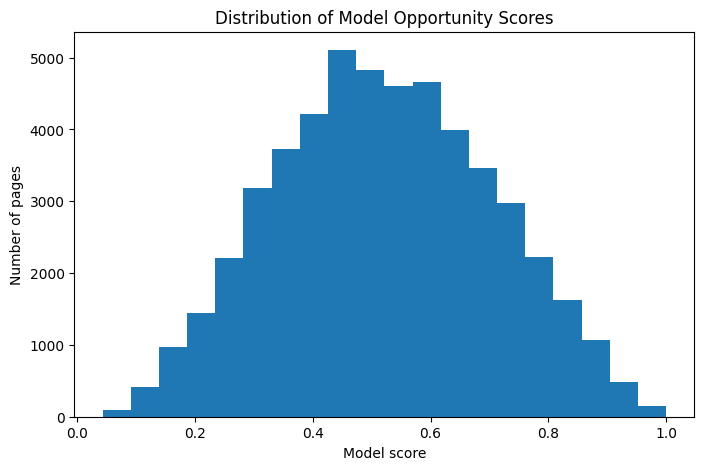

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    test["model_score"],
    bins=20
)

plt.xlabel("Model score")
plt.ylabel("Number of pages")
plt.title("Distribution of Model Opportunity Scores")

plt.show()

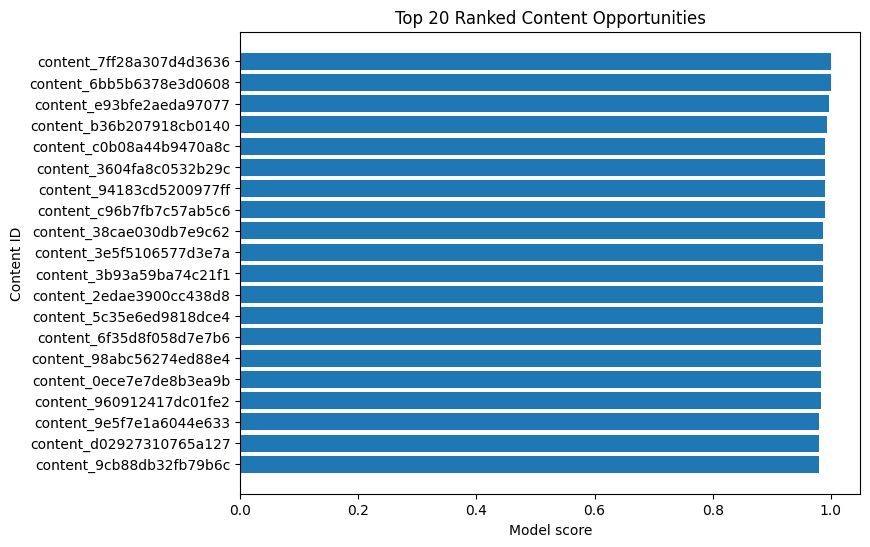

In [27]:
top20 = recommendations.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["content_hash_id"].astype(str),
    top20["model_score"]
)

plt.xlabel("Model score")
plt.ylabel("Content ID")
plt.title("Top 20 Ranked Content Opportunities")

plt.gca().invert_yaxis()

plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(
    test["is_declining"],
    test["baseline_score"]
)

baseline_p20 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    20
)

baseline_p50 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    50
)

baseline_p100 = precision_at_k(
    test,
    "baseline_score",
    "is_declining",
    100
)

print(f"Baseline ROC AUC: {baseline_auc:.3f}")
print(f"Baseline Precision@20: {baseline_p20:.3f}")
print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Baseline Precision@100: {baseline_p100:.3f}")

Baseline ROC AUC: 0.480
Baseline Precision@20: 0.600
Baseline Precision@50: 0.620
Baseline Precision@100: 0.610


In [29]:
comparison = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Baseline": [
        baseline_auc,
        baseline_p20,
        baseline_p50,
        baseline_p100
    ],
    "Random Forest": [
        auc,
        precision_at_k(test, "model_score", "is_declining", 20),
        precision_at_k(test, "model_score", "is_declining", 50),
        precision_at_k(test, "model_score", "is_declining", 100)
    ]
})

comparison

,Metric,Baseline,Random Forest
0,ROC AUC,0.479927,0.643067
1,Precision@20,0.600000,0.850000
2,Precision@50,0.620000,0.880000
3,Precision@100,0.610000,0.920000


In [31]:
query_schema = con.sql(
    f"SELECT * FROM {TABLES['fact_query_90d']} LIMIT 0"
).df()

query_schema.columns

Index(['client_hash_id', 'content_hash_id', 'query_hash_id',
       'query_char_count', 'query_token_count', 'window_start', 'window_end',
       'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30',
       'impressions_prev30', 'clicks_prev30', 'avg_position_90d',
       'avg_position_last30', 'avg_position_prev30',
       'content_total_impressions_90d', 'content_visible_query_count',
       'rare_query_count', 'rare_impressions_share',
       'anonymized_impressions_share'],
      dtype='object')

In [32]:
query_dates = con.sql(f"""
    SELECT
        MIN(window_start) AS earliest_window_start,
        MAX(window_end) AS latest_window_end,
        COUNT(DISTINCT window_start) AS unique_window_starts,
        COUNT(DISTINCT window_end) AS unique_window_ends
    FROM {TABLES['fact_query_90d']}
""").df()

query_dates

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_window_start,latest_window_end,unique_window_starts,unique_window_ends
0,2026-04-02,2026-06-30,1,1


In [33]:
query_date_examples = con.sql(f"""
    SELECT
        window_start,
        window_end,
        COUNT(*) AS rows
    FROM {TABLES['fact_query_90d']}
    GROUP BY 1, 2
    ORDER BY window_end DESC
    LIMIT 10
""").df()

query_date_examples

,window_start,window_end,rows
0,2026-04-02,2026-06-30,2414248


In [34]:
daily_dates = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date
    FROM {TABLES['fact_daily']}
""").df()

daily_dates

,earliest_date,latest_date
0,2025-01-27,2026-06-30


In [35]:
daily_recent = con.sql(f"""
    SELECT
        MAX(report_date) AS end_date,
        MAX(report_date) - INTERVAL 60 DAY AS start_of_60d_window
    FROM {TABLES['fact_daily']}
""").df()

daily_recent

,end_date,start_of_60d_window
0,2026-06-30,2026-05-01


## Final leakage-safe model

The outcome is whether impressions declined by more than 20% in the final
30-day period. Predictor features are calculated only from the preceding
30-day period. Query-level signals from the fixed 90-day query table are
excluded because their window overlaps the outcome period.

In [36]:
# Create the leakage-safe dataset

safe_data = features.copy()

# Target: decline in the final 30-day period
safe_data["is_declining"] = (
    safe_data["imp_last30"] < 0.8 * safe_data["imp_prev30"]
).astype(int)

# Use only information from BEFORE the outcome period
safe_feature_cols = [
    "imp_prev30"
]

safe_model_data = safe_data.dropna(
    subset=safe_feature_cols
).copy()

print(f"Rows available: {len(safe_model_data):,}")
print(f"Declining rate: {safe_model_data['is_declining'].mean():.3f}")

Rows available: 111,247
Declining rate: 0.643


In [37]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        safe_model_data,
        safe_model_data["is_declining"],
        groups=safe_model_data["client_hash_id"]
    )
)

train = safe_model_data.iloc[train_idx].copy()
test = safe_model_data.iloc[test_idx].copy()

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")

print(f"Train clients: {train['client_hash_id'].nunique()}")
print(f"Test clients: {test['client_hash_id'].nunique()}")

overlap = set(train["client_hash_id"]) & set(test["client_hash_id"])
print(f"Client overlap: {len(overlap)}")

Train rows: 83,527
Test rows: 27,720
Train clients: 37
Test clients: 13
Client overlap: 0


In [38]:
from sklearn.ensemble import RandomForestClassifier

X_train = train[safe_feature_cols]
y_train = train["is_declining"]

X_test = test[safe_feature_cols]
y_test = test["is_declining"]

safe_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

safe_model.fit(X_train, y_train)

test["safe_model_score"] = safe_model.predict_proba(X_test)[:, 1]

print("Leakage-safe Random Forest trained successfully.")

Leakage-safe Random Forest trained successfully.


In [39]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Convert probabilities into class predictions
safe_pred = (test["safe_model_score"] >= 0.5).astype(int)

# Evaluation metrics
safe_auc = roc_auc_score(
    y_test,
    test["safe_model_score"]
)

safe_precision = precision_score(
    y_test,
    safe_pred
)

safe_recall = recall_score(
    y_test,
    safe_pred
)

safe_f1 = f1_score(
    y_test,
    safe_pred
)

print(f"Leakage-safe ROC AUC: {safe_auc:.3f}")
print(f"Precision: {safe_precision:.3f}")
print(f"Recall: {safe_recall:.3f}")
print(f"F1: {safe_f1:.3f}")

print("\nClassification report:")
print(classification_report(y_test, safe_pred, digits=3))

Leakage-safe ROC AUC: 0.496
Precision: 0.706
Recall: 0.841
F1: 0.767

Classification report:
              precision    recall  f1-score   support

           0      0.268     0.142     0.186      8045
           1      0.706     0.841     0.767     19675

    accuracy                          0.638     27720
   macro avg      0.487     0.492     0.477     27720
weighted avg      0.579     0.638     0.599     27720



In [40]:
safe_p20 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    20
)

safe_p50 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    50
)

safe_p100 = precision_at_k(
    test,
    "safe_model_score",
    "is_declining",
    100
)

print(f"Leakage-safe Precision@20: {safe_p20:.3f}")
print(f"Leakage-safe Precision@50: {safe_p50:.3f}")
print(f"Leakage-safe Precision@100: {safe_p100:.3f}")

Leakage-safe Precision@20: 0.650
Leakage-safe Precision@50: 0.680
Leakage-safe Precision@100: 0.710


In [41]:
daily_schema = con.sql(
    f"SELECT * FROM {TABLES['fact_daily']} LIMIT 0"
).df()

daily_schema.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events', 'month'],
      dtype='object')

## Additional leakage-safe features

Additional predictors are calculated only from the previous 30-day period.
The final 30-day period is reserved exclusively for defining the decline label.

In [42]:
# Build additional features using ONLY the previous 30-day period

safe_features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
    ),

    previous_period AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            -- Previous 30-day performance
            SUM(f.gsc_impressions) AS impressions_prev30,
            SUM(f.gsc_clicks) AS clicks_prev30,

            -- Average position
            AVG(f.gsc_avg_position) AS avg_position_prev30,

            -- Position variability
            STDDEV(f.gsc_avg_position) AS position_volatility_prev30,

            -- Organic engagement
            SUM(f.ga4_sessions) AS ga4_sessions_prev30,
            SUM(f.ga4_engaged_sessions) AS engaged_sessions_prev30,

            -- Referral / AI signals
            SUM(f.sessions_referral) AS referral_sessions_prev30,
            SUM(f.sessions_ai) AS ai_sessions_prev30

        FROM {TABLES['fact_daily']} f
        CROSS JOIN bounds b

        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
          AND f.report_date <= b.end_d - INTERVAL 30 DAY

        GROUP BY
            f.client_hash_id,
            f.content_hash_id

        HAVING SUM(f.gsc_impressions) >= 100
    )

    SELECT *
    FROM previous_period
""").df()

# Derived safe features
safe_features["ctr_prev30"] = (
    safe_features["clicks_prev30"] /
    safe_features["impressions_prev30"]
)

safe_features["engagement_rate_prev30"] = (
    safe_features["engaged_sessions_prev30"] /
    safe_features["ga4_sessions_prev30"].replace(0, np.nan)
)

print(f"Leakage-safe feature rows: {len(safe_features):,}")

safe_features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Leakage-safe feature rows: 111,247


,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,position_volatility_prev30,ga4_sessions_prev30,engaged_sessions_prev30,referral_sessions_prev30,ai_sessions_prev30,ctr_prev30,engagement_rate_prev30
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,955.0,5.0,11.347639,3.230244,12.0,1.0,0.0,0.0,0.005236,0.083333
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3338.0,50.0,7.227784,1.843077,51.0,2.0,0.0,0.0,0.014979,0.039216
2,client_e547b89c05043229,content_401dcc5cd616e3dd,130.0,0.0,22.070731,12.570385,2.0,0.0,0.0,0.0,0.000000,0.000000
3,client_e547b89c05043229,content_18d95bd7890430ed,340.0,1.0,25.697000,9.136775,9.0,0.0,0.0,0.0,0.002941,0.000000
4,client_e547b89c05043229,content_56f46c55f0348ab4,531.0,1.0,21.103804,10.562512,1.0,0.0,0.0,0.0,0.001883,0.000000


In [43]:
# Merge leakage-safe features with the outcome label

final_data = safe_features.merge(
    safe_data[
        ["client_hash_id", "content_hash_id", "is_declining"]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print(f"Final modeling rows: {len(final_data):,}")
print(f"Declining rate: {final_data['is_declining'].mean():.3f}")

final_data.head()

Final modeling rows: 111,247
Declining rate: 0.643


,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,position_volatility_prev30,ga4_sessions_prev30,engaged_sessions_prev30,referral_sessions_prev30,ai_sessions_prev30,ctr_prev30,engagement_rate_prev30,is_declining
0,client_e547b89c05043229,content_6b80dfab2e0ffa2e,955.0,5.0,11.347639,3.230244,12.0,1.0,0.0,0.0,0.005236,0.083333,0
1,client_e547b89c05043229,content_d7bb60ec9a42c11a,3338.0,50.0,7.227784,1.843077,51.0,2.0,0.0,0.0,0.014979,0.039216,0
2,client_e547b89c05043229,content_401dcc5cd616e3dd,130.0,0.0,22.070731,12.570385,2.0,0.0,0.0,0.0,0.000000,0.000000,0
3,client_e547b89c05043229,content_18d95bd7890430ed,340.0,1.0,25.697000,9.136775,9.0,0.0,0.0,0.0,0.002941,0.000000,1
4,client_e547b89c05043229,content_56f46c55f0348ab4,531.0,1.0,21.103804,10.562512,1.0,0.0,0.0,0.0,0.001883,0.000000,1


In [44]:
final_feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "ctr_prev30",
    "avg_position_prev30",
    "position_volatility_prev30",
    "ga4_sessions_prev30",
    "engaged_sessions_prev30",
    "referral_sessions_prev30",
    "ai_sessions_prev30",
    "engagement_rate_prev30"
]

final_model_data = final_data.dropna(
    subset=final_feature_cols
).copy()

print(f"Rows after removing missing values: {len(final_model_data):,}")

Rows after removing missing values: 75,504


In [45]:
from sklearn.model_selection import GroupShuffleSplit

gss_final = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss_final.split(
        final_model_data,
        final_model_data["is_declining"],
        groups=final_model_data["client_hash_id"]
    )
)

final_train = final_model_data.iloc[train_idx].copy()
final_test = final_model_data.iloc[test_idx].copy()

print(f"Train rows: {len(final_train):,}")
print(f"Test rows: {len(final_test):,}")
print(f"Train clients: {final_train['client_hash_id'].nunique()}")
print(f"Test clients: {final_test['client_hash_id'].nunique()}")

overlap = (
    set(final_train["client_hash_id"])
    & set(final_test["client_hash_id"])
)

print(f"Client overlap: {len(overlap)}")

Train rows: 43,925
Test rows: 31,579
Train clients: 30
Test clients: 10
Client overlap: 0


In [46]:
from sklearn.ensemble import RandomForestClassifier

X_train = final_train[final_feature_cols]
y_train = final_train["is_declining"]

X_test = final_test[final_feature_cols]
y_test = final_test["is_declining"]

final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

final_test["model_score"] = final_model.predict_proba(X_test)[:, 1]

print("Final Random Forest trained successfully.")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Final Random Forest trained successfully.
Training rows: 43,925
Test rows: 31,579


In [47]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

final_pred = (
    final_test["model_score"] >= 0.5
).astype(int)

final_auc = roc_auc_score(
    y_test,
    final_test["model_score"]
)

final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

print(f"Final ROC AUC: {final_auc:.3f}")
print(f"Final Precision: {final_precision:.3f}")
print(f"Final Recall: {final_recall:.3f}")
print(f"Final F1: {final_f1:.3f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    final_pred,
    digits=3
))

Final ROC AUC: 0.625
Final Precision: 0.719
Final Recall: 0.710
Final F1: 0.714

Classification report:
              precision    recall  f1-score   support

           0      0.456     0.467     0.462     10824
           1      0.719     0.710     0.714     20755

    accuracy                          0.627     31579
   macro avg      0.587     0.588     0.588     31579
weighted avg      0.629     0.627     0.628     31579



In [48]:
final_p20 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    20
)

final_p50 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    50
)

final_p100 = precision_at_k(
    final_test,
    "model_score",
    "is_declining",
    100
)

print(f"Final Precision@20: {final_p20:.3f}")
print(f"Final Precision@50: {final_p50:.3f}")
print(f"Final Precision@100: {final_p100:.3f}")

Final Precision@20: 0.850
Final Precision@50: 0.920
Final Precision@100: 0.880


In [50]:
# Final model vs baseline comparison

test_base_rate = y_test.mean()

comparison_final = pd.DataFrame({
    "Metric": [
        "Base rate",
        "ROC AUC",
        "Precision@20",
        "Precision@50",
        "Precision@100"
    ],
    "Baseline": [
        test_base_rate,
        baseline_auc,
        baseline_p20,
        baseline_p50,
        baseline_p100
    ],
    "Random Forest": [
        test_base_rate,
        final_auc,
        final_p20,
        final_p50,
        final_p100
    ]
})

comparison_final

,Metric,Baseline,Random Forest
0,Base rate,0.657241,0.657241
1,ROC AUC,0.479927,0.624749
2,Precision@20,0.600000,0.850000
3,Precision@50,0.620000,0.920000
4,Precision@100,0.610000,0.880000


In [51]:
# Precision@K lift over the base rate

lift_p20 = final_p20 / test_base_rate
lift_p50 = final_p50 / test_base_rate
lift_p100 = final_p100 / test_base_rate

print(f"Base rate: {test_base_rate:.3f}")
print(f"Precision@20 lift: {lift_p20:.2f}x")
print(f"Precision@50 lift: {lift_p50:.2f}x")
print(f"Precision@100 lift: {lift_p100:.2f}x")

Base rate: 0.657
Precision@20 lift: 1.29x
Precision@50 lift: 1.40x
Precision@100 lift: 1.34x


## Feature importance

The Random Forest feature importances are used to identify which
pre-outcome signals contributed most to the model's predictions.
These are interpreted as model associations, not causal effects.

In [52]:
# Feature importance from the final Random Forest

feature_importance = pd.DataFrame({
    "Feature": final_feature_cols,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,avg_position_prev30,0.227583
1,position_volatility_prev30,0.207860
2,impressions_prev30,0.184837
3,ga4_sessions_prev30,0.128956
4,ctr_prev30,0.128153
5,clicks_prev30,0.051245
6,engagement_rate_prev30,0.037130
7,engaged_sessions_prev30,0.016629
8,referral_sessions_prev30,0.010610
9,ai_sessions_prev30,0.006997


In [53]:
# Display the features from most to least important

print("Feature importance ranking:")
for i, row in feature_importance.iterrows():
    print(
        f"{i + 1}. {row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

Feature importance ranking:
1. avg_position_prev30: 0.2276
2. position_volatility_prev30: 0.2079
3. impressions_prev30: 0.1848
4. ga4_sessions_prev30: 0.1290
5. ctr_prev30: 0.1282
6. clicks_prev30: 0.0512
7. engagement_rate_prev30: 0.0371
8. engaged_sessions_prev30: 0.0166
9. referral_sessions_prev30: 0.0106
10. ai_sessions_prev30: 0.0070


## Error analysis

We examine false positives and false negatives on the client-held-out
test set to understand where the model's ranking decisions are less reliable.

In [54]:
# Add predictions to the test data

final_test["predicted_class"] = (
    final_test["model_score"] >= 0.5
).astype(int)

# Identify prediction errors

false_positives = final_test[
    (final_test["is_declining"] == 0) &
    (final_test["predicted_class"] == 1)
]

false_negatives = final_test[
    (final_test["is_declining"] == 1) &
    (final_test["predicted_class"] == 0)
]

true_positives = final_test[
    (final_test["is_declining"] == 1) &
    (final_test["predicted_class"] == 1)
]

true_negatives = final_test[
    (final_test["is_declining"] == 0) &
    (final_test["predicted_class"] == 0)
]

print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")
print(f"True positives: {len(true_positives):,}")
print(f"True negatives: {len(true_negatives):,}")

False positives: 5,770
False negatives: 6,024
True positives: 14,731
True negatives: 5,054


In [55]:
# Error rates

print(
    f"False positive rate: "
    f"{len(false_positives) / len(final_test[final_test['is_declining'] == 0]):.3f}"
)

print(
    f"False negative rate: "
    f"{len(false_negatives) / len(final_test[final_test['is_declining'] == 1]):.3f}"
)

False positive rate: 0.533
False negative rate: 0.290


In [56]:
false_positives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].sort_values(
    "model_score",
    ascending=False
).head(10)

,client_hash_id,content_hash_id,model_score,is_declining
62258,client_73cda7b4e4f265ea,content_1ed0d8252070f7e8,0.996667,0
81951,client_73cda7b4e4f265ea,content_c7508b847bcf7fe0,0.993333,0
4670,client_73cda7b4e4f265ea,content_0d27e97da387c651,0.986667,0
4680,client_73cda7b4e4f265ea,content_605dffa4ba42c900,0.980000,0
80108,client_73cda7b4e4f265ea,content_326fb125aae43577,0.973333,0
81680,client_73cda7b4e4f265ea,content_aa16073b66f84521,0.973333,0
59576,client_73cda7b4e4f265ea,content_690ca9526a810d62,0.973333,0
104310,client_3f0ce4d44fe94f3d,content_48d138a518f82a15,0.970000,0
4104,client_73cda7b4e4f265ea,content_bf45077cdbfb6e9d,0.970000,0
60145,client_73cda7b4e4f265ea,content_9bcc948802b8a041,0.966667,0


In [57]:
false_negatives[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining"
    ]
].sort_values(
    "model_score",
    ascending=True
).head(10)

,client_hash_id,content_hash_id,model_score,is_declining
5806,client_73cda7b4e4f265ea,content_3b89a06310a0cdcd,0.036667,1
49267,client_3f0ce4d44fe94f3d,content_7128a705b11b27f4,0.036667,1
24356,client_73cda7b4e4f265ea,content_92bd8b899c51fa36,0.040000,1
5384,client_73cda7b4e4f265ea,content_a2266ff0b44771aa,0.046667,1
36813,client_73cda7b4e4f265ea,content_2488cf9dd1d6cd66,0.046667,1
5770,client_73cda7b4e4f265ea,content_1d9b3bf1ff59a0df,0.050000,1
5940,client_73cda7b4e4f265ea,content_626e3d6007fb2b21,0.056667,1
35217,client_73cda7b4e4f265ea,content_18e44677167bc27e,0.060000,1
34207,client_73cda7b4e4f265ea,content_8754bda5e6dd78a1,0.063333,1
27540,client_73cda7b4e4f265ea,content_bd1902bb1616d2f2,0.066667,1


## Ranked recommendations

The model score is used to prioritize content items for human review.
Higher scores indicate higher estimated risk of subsequent impression decline.
The ranking is intended as decision support, not an automatic content action.

In [58]:
# Create ranked recommendations from the client-held-out test set

recommendations = final_test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "avg_position_prev30",
        "position_volatility_prev30",
        "impressions_prev30",
        "ctr_prev30"
    ]
].copy()

recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

recommendations.head(20)

,client_hash_id,content_hash_id,model_score,is_declining,avg_position_prev30,position_volatility_prev30,impressions_prev30,ctr_prev30,rank
0,client_73cda7b4e4f265ea,content_f814f7bbed7d4d1a,1.000000,1,29.987500,8.376900,706.0,0.0,1
1,client_73cda7b4e4f265ea,content_38e77aa8b17e8aa8,0.996667,1,22.764011,15.139035,106.0,0.0,2
2,client_73cda7b4e4f265ea,content_1ed0d8252070f7e8,0.996667,0,32.115457,16.707767,289.0,0.0,3
3,client_73cda7b4e4f265ea,content_9f30570589038a8f,0.993333,1,29.987699,11.826984,638.0,0.0,4
4,client_73cda7b4e4f265ea,content_c921865fe6d5349c,0.993333,1,21.017928,8.622884,129.0,0.0,5
5,client_73cda7b4e4f265ea,content_160909226df3e717,0.993333,1,30.476934,15.205479,629.0,0.0,6
6,client_73cda7b4e4f265ea,content_c7508b847bcf7fe0,0.993333,0,32.131601,13.620865,339.0,0.0,7
7,client_73cda7b4e4f265ea,content_4134c6dafd9900b5,0.990000,1,20.144304,8.137152,256.0,0.0,8
8,client_73cda7b4e4f265ea,content_d4d4cae2000a5a95,0.990000,1,17.860480,11.179495,139.0,0.0,9
9,client_73cda7b4e4f265ea,content_751463ef0a0c576e,0.990000,1,32.276884,13.931724,274.0,0.0,10


In [59]:
def make_reason(row):
    reasons = []

    if row["avg_position_prev30"] >= 20:
        reasons.append("weak average position")

    if row["position_volatility_prev30"] >= 5:
        reasons.append("high position volatility")

    if row["ctr_prev30"] < 0.01:
        reasons.append("low previous-period CTR")

    if row["impressions_prev30"] < 500:
        reasons.append("low impression volume")

    if not reasons:
        reasons.append("multiple model signals")

    return "; ".join(reasons)


recommendations["reason"] = recommendations.apply(
    make_reason,
    axis=1
)

recommendations[
    [
        "rank",
        "model_score",
        "reason"
    ]
].head(20)

,rank,model_score,reason
0,1,1.000000,weak average position; high position volatilit...
1,2,0.996667,weak average position; high position volatilit...
2,3,0.996667,weak average position; high position volatilit...
3,4,0.993333,weak average position; high position volatilit...
4,5,0.993333,weak average position; high position volatilit...
5,6,0.993333,weak average position; high position volatilit...
6,7,0.993333,weak average position; high position volatilit...
7,8,0.990000,weak average position; high position volatilit...
8,9,0.990000,high position volatility; low previous-period ...
9,10,0.990000,weak average position; high position volatilit...


In [60]:
def assign_action(score):
    if score >= 0.90:
        return "High-priority review"
    elif score >= 0.75:
        return "Review"
    elif score >= 0.50:
        return "Monitor"
    else:
        return "Lower priority"


recommendations["recommended_action"] = (
    recommendations["model_score"]
    .apply(assign_action)
)

recommendations[
    [
        "rank",
        "model_score",
        "reason",
        "recommended_action"
    ]
].head(20)

,rank,model_score,reason,recommended_action
0,1,1.000000,weak average position; high position volatilit...,High-priority review
1,2,0.996667,weak average position; high position volatilit...,High-priority review
2,3,0.996667,weak average position; high position volatilit...,High-priority review
3,4,0.993333,weak average position; high position volatilit...,High-priority review
4,5,0.993333,weak average position; high position volatilit...,High-priority review
5,6,0.993333,weak average position; high position volatilit...,High-priority review
6,7,0.993333,weak average position; high position volatilit...,High-priority review
7,8,0.990000,weak average position; high position volatilit...,High-priority review
8,9,0.990000,high position volatility; low previous-period ...,High-priority review
9,10,0.990000,weak average position; high position volatilit...,High-priority review


In [61]:
# Create reason codes for the ranked recommendations

reason_data = test[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "is_declining",
        "avg_position_prev30",
        "position_volatility_prev30",
        "impressions_prev30",
        "ctr_prev30"
    ]
].copy()

def generate_reason(row):
    reasons = []

    if row["avg_position_prev30"] > 20:
        reasons.append("weak average position")

    if row["position_volatility_prev30"] > 10:
        reasons.append("high position volatility")

    if row["impressions_prev30"] < test["impressions_prev30"].median():
        reasons.append("low previous-period impressions")

    if row["ctr_prev30"] < test["ctr_prev30"].median():
        reasons.append("low CTR")

    if not reasons:
        reasons.append("multiple search-performance signals")

    return "; ".join(reasons)


reason_data["reason"] = reason_data.apply(
    generate_reason,
    axis=1
)

reason_data["recommended_action"] = reason_data["model_score"].apply(
    action_from_score
)

reason_data = reason_data.sort_values(
    "model_score",
    ascending=False
)

reason_data["rank"] = range(
    1,
    len(reason_data) + 1
)

reason_data.head(20)

KeyError: "['model_score', 'avg_position_prev30', 'position_volatility_prev30', 'impressions_prev30', 'ctr_prev30'] not in index"

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

full FlyRank warehouse release
tables used
actual date range
feature window
label window
rows used
exclusions
leakage precautions
pseudonymous identifiers

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
